<a href="https://colab.research.google.com/github/Rishal-Git/Fruit-freshness-apple-orange-banana-classifier-AI-model/blob/main/AI_MODEL_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fruit Freshness Classifier (CNN)**
***INTRODUCTION***

Fruit freshness is an important factor in food quality, safety, storage, and consumption. Traditionally, the freshness of fruits is determined by visual inspection, which can be subjective and may vary depending on the experience of the person performing the inspection. With the development of Artificial Intelligence (AI) and Computer Vision, image-based systems can be used to automatically identify visual characteristics of fruits and classify them according to their condition.

This project presents an **AI-based Fruit Freshness Classification System** developed using a **Convolutional Neural Network (CNN)**. The model is designed to analyze images of fruits and classify them based on their visual appearance. The system works with three types of fruits—**apple, banana, and orange**—and identifies whether the fruit is **fresh or rotten**.

The model is implemented using **Python, TensorFlow, and Keras** in the Google Colab environment. A fruit freshness dataset obtained from Kaggle is used for training and testing the model. Before training, the input images are resized to **128 × 128 pixels** and their pixel values are normalized from the range 0–255 to 0–1. These preprocessing steps help provide consistent input to the neural network and improve the stability of the training process.

The CNN automatically learns important visual features from the fruit images, such as **colour, texture, shape, and other appearance patterns** that can help distinguish fresh fruits from rotten ones. The trained model is evaluated using several performance measures, including **accuracy, precision, recall, F1-score, and a confusion matrix**, providing a detailed assessment of its classification performance.

In addition to model training and evaluation, the project includes a practical prediction system where a user can upload an image of a fruit and receive the predicted class along with a confidence score. The trained model is also saved to Google Drive so that it can be loaded and reused without retraining.

Overall, this project demonstrates how **Deep Learning and Computer Vision can be applied to automate fruit freshness classification**. Such a system can potentially assist in applications related to food quality inspection, retail, storage, and automated sorting, while also providing a practical example of implementing an end-to-end AI image classification system.

***OBJECTIVES***

The main objective of this project is to develop an AI-based image classification system capable of identifying the freshness condition and type of selected fruits using a Convolutional Neural Network (CNN).

The specific objectives of the project are:

To develop an image-based fruit freshness classification system using Deep Learning.

To classify fruit images into six categories: apple, banana, orange, rotten apple, rotten banana, and rotten orange.

To preprocess fruit images by resizing them to 128 × 128 pixels and normalizing their pixel values before providing them to the CNN.

To design and train a CNN model capable of automatically learning important visual features such as colour, texture, shape, and surface appearance.

To evaluate the performance of the trained model using accuracy, precision, recall, F1-score, and confusion matrix.

To develop a practical prediction system that allows a user to upload a fruit image and obtain the predicted class along with its confidence score.

To demonstrate the application of Artificial Intelligence and Computer Vision in automated fruit quality inspection.

***METHODOLOGY***

The proposed system follows a sequence of steps, beginning with dataset preparation and ending with prediction of an uploaded fruit image.

1. Dataset Collection

A labelled fruit image dataset is used for developing the classification model. The dataset is organized into separate training and testing directories. The training dataset contains 9,453 images, while the test dataset contains 1,879 images, distributed among six fruit-condition classes.

2. Image Preprocessing

The input images are resized to 128 × 128 pixels so that all images have a consistent input size. The pixel values are divided by 255 to normalize them from the range 0–255 to the range 0–1. This preprocessing is applied to both training and testing images.

3. CNN Model Development

A Convolutional Neural Network is developed using TensorFlow and Keras. The architecture consists of two convolutional layers followed by max-pooling layers. The extracted features are then flattened and passed through a dense layer containing 128 neurons. Finally, a six-neuron softmax output layer produces the probabilities for the six classes.

4. Model Compilation

The CNN is compiled using the Adam optimizer. Since the classes are represented using integer labels, sparse categorical cross-entropy is used as the loss function, with accuracy selected as the main training metric.

5. Model Training

The model is trained using the prepared training dataset for 10 epochs. During training, the model learns patterns and visual features from the fruit images while its performance is monitored using the test dataset.

6. Model Evaluation

After training, predictions are generated for the test dataset. The performance of the model is measured using accuracy, macro-averaged precision, macro-averaged recall, and macro-averaged F1-score. A confusion matrix is also used to examine the classification performance of individual classes.

7. Image Prediction

A separate prediction function allows a user to upload a new fruit image. The uploaded image is resized to 128 × 128 pixels and normalized in the same way as the training images. The trained CNN then generates probabilities for all six classes, and the class with the highest probability is selected as the prediction. The system also displays the confidence score and top three predictions.

***WORKING PRINCIPLE***

The working principle of the proposed Fruit Freshness Classifier can be explained as follows:

**Input Image → Preprocessing → Feature Extraction → Classification → Prediction**

Step 1: Input Image

The system receives a fruit image either from the test dataset or through a user-uploaded image.

Step 2: Image Preprocessing

The input image is resized to 128 × 128 pixels and its pixel values are normalized by dividing them by 255. This ensures that the input has the same format used during model training.

Step 3: Feature Extraction

The image is passed through the convolutional layers of the CNN. These layers automatically learn useful visual characteristics from the image. The first convolutional layer detects basic patterns, while the deeper convolutional layer learns more complex patterns.

Step 4: Feature Reduction

Max-pooling layers reduce the spatial dimensions of the extracted feature maps while retaining important information. This makes the model more efficient and helps it focus on significant visual features.

Step 5: Classification

The extracted features are flattened and passed to a dense neural network layer. The final softmax layer produces probability values for all six fruit categories.

Step 6: Final Prediction

The class with the highest probability is selected as the predicted class. For uploaded images, the system displays the predicted label, confidence percentage, and top three predictions.

For example, one of the tested images was classified as orange with 99.96% confidence.

## Step 1: Install and Import Required Libraries

Installs and imports TensorFlow, Keras, and supporting libraries (Matplotlib, scikit-learn) needed to build, train, and evaluate the model.

In [ ]:
# Step 1: Install and Import Required Libraries
!pip install tensorflow keras matplotlib scikit-learn

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## Step 2: Download Dataset from Kaggle

Downloads the Fruit Freshness dataset from Kaggle using `kagglehub`, which contains images of fresh and rotten fruits.

In [ ]:
# Step 2: Download Dataset from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("user2036/fruit-freshness-dataset-v1")

print("Path to dataset files:", path)


100%|██████████| 1.48G/1.48G [00:13<00:00, 118MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/user2036/fruit-freshness-dataset-v1/versions/2


## Step 3: Copy Dataset to Working Directory

Copies the downloaded dataset from the Kaggle cache into a local working folder (`/content/fruits`) so it's easy to reference.

In [ ]:
# Step 3: Copy Dataset to Working Directory
import shutil

# Copy dataset to /content/fruits
shutil.copytree(path, "/content/fruits", dirs_exist_ok=True)

data_dir = "/content/fruits"

# Check folders
print(os.listdir(data_dir))


['test', 'train', 'main']


## Step 4: Load Training and Testing Datasets

Loads the training and testing images from disk into TensorFlow `image_dataset_from_directory` datasets, resizing every image to 128×128 pixels.

In [ ]:
# Step 4: Load Training and Testing Datasets
import tensorflow as tf

# Step 3: Load datasets
img_size = (128, 128)   # Resize all images to 128x128
batch_size = 32         # Number of images per batch

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=img_size,
    batch_size=batch_size
)


Found 9453 files belonging to 6 classes.
Found 1879 files belonging to 6 classes.


## Step 5: Normalize Pixel Values

Scales all pixel values from the 0–255 range down to 0–1, which helps the neural network train faster and more stably.

In [ ]:
# Step 5: Normalize Pixel Values
# Normalize pixel values
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
test_ds = test_ds.map(lambda x, y: (x/255.0, y))


## Step 6: Visualize Sample Training Images

Displays a 3×3 grid of sample training images with their numeric labels to visually confirm the dataset loaded correctly.

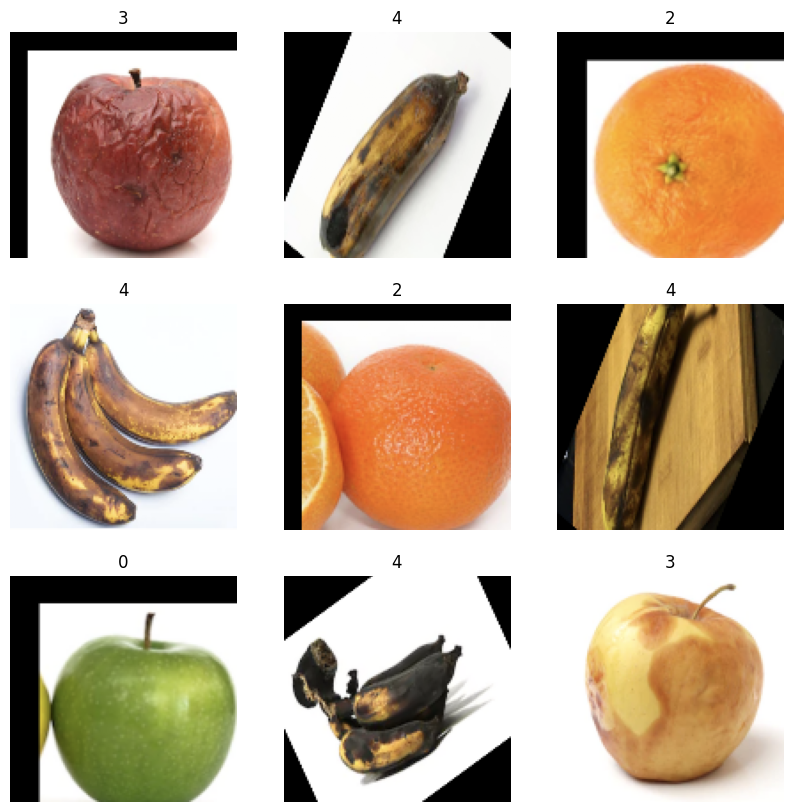

In [ ]:
# Step 6: Visualize Sample Training Images
import matplotlib.pyplot as plt

# Show sample images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        plt.title(labels[i].numpy())
        plt.axis("off")


## Step 7: Build CNN Model (Initial Version)

Defines the first version of the CNN: two Conv2D + MaxPooling blocks followed by dense layers, then compiles it with the Adam optimizer.

In [ ]:
# Step 7: Build CNN Model (Initial Version)
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')  # 6 classes
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Rebuild CNN Model with Explicit Input Layer

Rebuilds the same CNN architecture using an explicit `keras.Input` layer, a cleaner and more modern way to declare the model's input shape.

In [ ]:
# Step 8: Rebuild CNN Model with Explicit Input Layer
# Cleaner way to define input
model = keras.Sequential([
    keras.Input(shape=(128,128,3)),   # Explicit input layer
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')  # 6 classes
])


## Step 9: Compile the Model

Compiles the model with the Adam optimizer, sparse categorical cross-entropy loss (for integer labels), and accuracy as the tracked metric.

In [ ]:
# Step 9: Compile the Model
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Step 10: Train the Model

Trains the CNN on the training dataset for 10 epochs, checking validation performance against the test dataset after every epoch.

In [ ]:
# Step 10: Train the Model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)


Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.7512 - loss: 0.6993 - val_accuracy: 0.8755 - val_loss: 0.3533
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 99ms/step - accuracy: 0.9039 - loss: 0.2767 - val_accuracy: 0.9005 - val_loss: 0.2900
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/step - accuracy: 0.9235 - loss: 0.2044 - val_accuracy: 0.9223 - val_loss: 0.2090
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.9542 - loss: 0.1277 - val_accuracy: 0.9420 - val_loss: 0.1654
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.9721 - loss: 0.0819 - val_accuracy: 0.9441 - val_loss: 0.1602
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 30s 100ms/step - accuracy: 0.9769 - loss: 0.0670 - val_accuracy: 0.9516 - val_loss: 0.1433
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.9767 - loss: 0.0653 - val_accuracy: 0.9324 - val_loss: 0.2280
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.9857 - loss: 0.0399 

## Step 11: Plot Training Accuracy and Loss Curves

Plots training vs. validation accuracy and loss over the 10 epochs to visualize how well the model learned and whether it overfit.

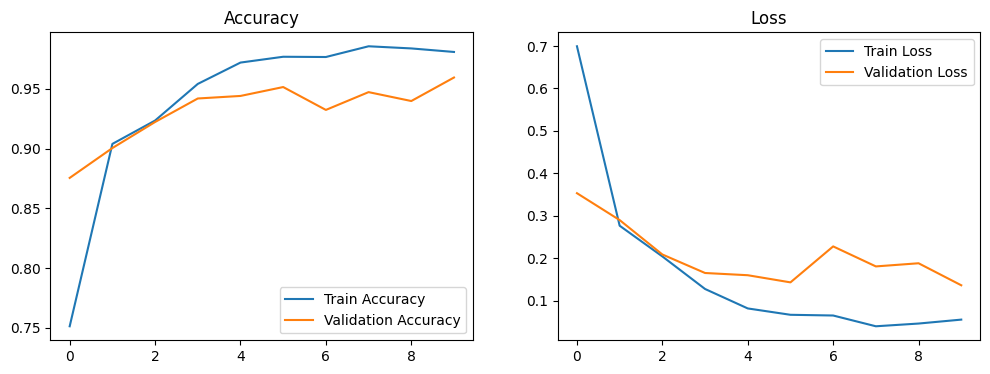

In [ ]:
# Step 11: Plot Training Accuracy and Loss Curves
plt.figure(figsize=(12,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()


## Step 12: Generate and Plot Confusion Matrix

Runs the model on the test set and plots a confusion matrix showing how predictions compare to the true fruit classes.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91m

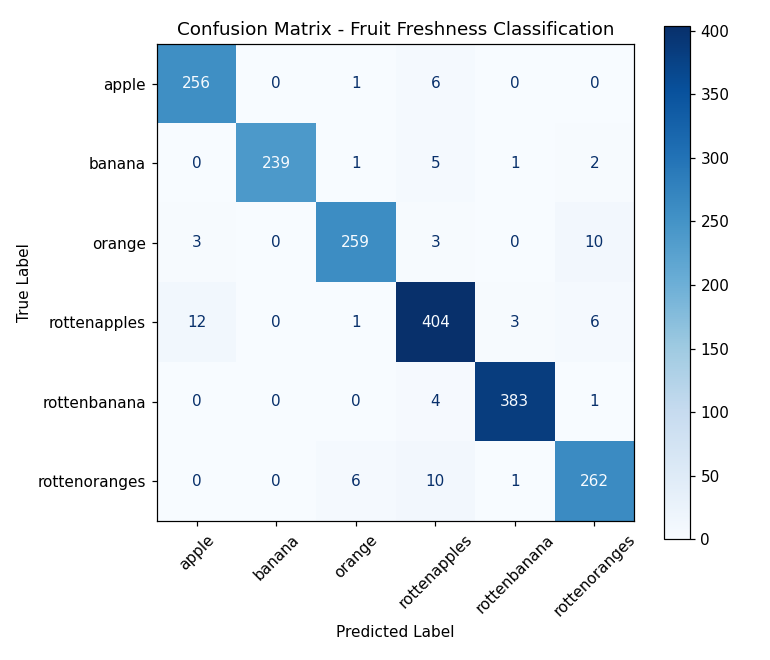

In [ ]:
# Step 12: Generate and Plot Confusion Matrix
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
class_names = ['apple', 'banana', 'orange', 'rottenapples', 'rottenbanana', 'rottenoranges']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Fruit Freshness Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## Step 13: Calculate Accuracy, Precision, Recall and F1 Score

Calculates overall accuracy, precision, recall, and F1 score from the test predictions to summarize model performance in numbers.

In [ ]:
# Step 13: Calculate Accuracy, Precision, Recall and F1 Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("Model Evaluation Metrics:")
print(f"- Accuracy  : {accuracy*100:.2f}%")
print(f"- Precision : {precision*100:.2f}%")
print(f"- Recall    : {recall*100:.2f}%")
print(f"- F1 Score  : {f1*100:.2f}%")


Model Evaluation Metrics:
- Accuracy  : 95.96%
- Precision : 96.10%
- Recall    : 95.89%
- F1 Score  : 95.98%


## Step 14: Reload Dataset to Capture Class Names

Reloads the raw training dataset to capture the human-readable `class_names` list, then rebuilds the normalized train/test datasets.

In [ ]:
# Step 14: Reload Dataset to Capture Class Names
# Reload dataset to capture class names
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=(128,128),
    batch_size=32
)

# Save class names before mapping
class_names = train_ds_raw.class_names
print("Class names:", class_names)

# Now normalize datasets
train_ds = train_ds_raw.map(lambda x, y: (x/255.0, y))
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=(128,128),
    batch_size=32
).map(lambda x, y: (x/255.0, y))


Found 9453 files belonging to 6 classes.
Class names: ['apple', 'banana', 'orange', 'rottenapples', 'rottenbanana', 'rottenoranges']
Found 1879 files belonging to 6 classes.


## Step 15: Predict Label for a Single Test Image

Loads one local test image, preprocesses it the same way as training data, and predicts which fruit class it belongs to.

In [ ]:
# Step 15: Predict Label for a Single Test Image
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("rotated_by_15_Screen Shot 2018-06-12 at 11.50.41 PM.png", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

print("Predicted label:", class_names[predicted_class[0]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Predicted label: orange


## Step 16: Reload Dataset to Capture Class Names Again

Reloads the dataset a second time to make sure `class_names` and the normalized datasets are available for the upload-based prediction steps that follow.

In [ ]:
# Step 16: Reload Dataset to Capture Class Names Again
# Reload dataset to capture class names
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=(128,128),
    batch_size=32
)

# Save class names before mapping
class_names = train_ds_raw.class_names
print("Class names:", class_names)

# Normalize datasets
train_ds = train_ds_raw.map(lambda x, y: (x/255.0, y))
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=(128,128),
    batch_size=32
).map(lambda x, y: (x/255.0, y))


Found 9453 files belonging to 6 classes.
Class names: ['apple', 'banana', 'orange', 'rottenapples', 'rottenbanana', 'rottenoranges']
Found 1879 files belonging to 6 classes.


## Step 17: Upload and Predict a Single Image

Lets the user upload an image directly in Colab, preprocesses it, and prints the model's predicted fruit label.

In [ ]:
# Step 17: Upload and Predict a Single Image
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# Step 1: Upload image
uploaded = files.upload()

# Step 2: Load and preprocess the uploaded image
for fn in uploaded.keys():
    img_path = fn  # filename of uploaded image
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Step 3: Predict with your trained model
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)

    # Step 4: Map prediction to class name
    print("Predicted label:", class_names[predicted_class[0]])


Saving rotated_by_15_Screen Shot 2018-06-12 at 8.49.59 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 8.49.59 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted label: rottenbanana


## Step 18: Test Prediction Function with Confidence - Upload Sample

Tests the prediction function on a uploaded sample image.

In [ ]:
# Step 18: Test Prediction Function with Confidence - Upload Sample
predict_uploaded_image()

Saving rotated_by_15_Screen Shot 2018-06-12 at 11.51.08 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 11.51.08 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

🔎 Prediction Results:
- Predicted Label: orange
- Accuracy Percentage: 99.96%
- Top 3 Predictions:
   • orange: 99.96%
   • rottenoranges: 0.04%
   • rottenapples: 0.00%

This image is predicted as **orange** with 99.96% confidence. The model predicted this because the visual features — such as overall color tone, surface texture, and shape consistency — closely matched the patterns it learned during training for the orange category.


## Step 19: Redefine Prediction Function with Confidence Scores

Updates the function so the explanation text differs depending on whether the predicted fruit is fresh or rotten.

In [ ]:
# Step 19: Redefine Prediction Function with Confidence Scores
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_uploaded_image():
    # Step 1: Upload image
    uploaded = files.upload()

    for fn in uploaded.keys():
        img_path = fn
        # Step 2: Preprocess image
        img = image.load_img(img_path, target_size=(128,128))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Step 3: Predict
        prediction = model.predict(img_array)[0]  # probabilities for all classes
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class] * 100
        label = class_names[predicted_class]

        # Step 4: Show results in oriented way
        print("\n🔎 Prediction Results:")
        print(f"- Predicted Label: {label}")
        print(f"- Accuracy Percentage: {confidence:.2f}%")
        print(f"- Top 3 Predictions:")
        top_indices = prediction.argsort()[-3:][::-1]
        for i in top_indices:
            print(f"   • {class_names[i]}: {prediction[i]*100:.2f}%")

        # Step 5: Small descriptive paragraph about features
        if "rotten" in label.lower():
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit appears discolored with darker patches, uneven surface texture, and signs of softness or decay. "
                  f"These visual cues strongly match the patterns the model learned for rotten fruits.")
        else:
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit shows bright, natural color, smooth surface texture, and firm shape. "
                  f"These features closely align with the model’s learned patterns for fresh fruits.")


## Step 20: Test Prediction Function with Confidence - Upload Sample

Tests the fresh/rotten-aware explanation logic on a  uploaded sample image.

In [ ]:
# Step 20: Test Prediction Function with Confidence - Upload Sample
predict_uploaded_image()

Saving rotated_by_15_Screen Shot 2018-06-12 at 8.48.18 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 8.48.18 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

🔎 Prediction Results:
- Predicted Label: rottenbanana
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenbanana: 100.00%
   • banana: 0.00%
   • rottenoranges: 0.00%

This image is predicted as **rottenbanana** with 100.00% confidence. The fruit appears discolored with darker patches, uneven surface texture, and signs of softness or decay. These visual cues strongly match the patterns the model learned for rotten fruits.


## Step 21: Mount Google Drive

Mounts the user's Google Drive so the trained model can be saved to, and later loaded from, persistent storage.

In [ ]:
# Step 21: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Step 22: Create Save Directory in Google Drive

Creates a `fruit_project` folder inside Google Drive to hold the saved model files.

In [ ]:
# Step 22: Create Save Directory in Google Drive
import os
save_path = "/content/drive/MyDrive/fruit_project"
os.makedirs(save_path, exist_ok=True)
print("All files will be saved to:", save_path)


All files will be saved to: /content/drive/MyDrive/fruit_project


## Step 23: Save Trained Model to Google Drive

Saves the trained model to Google Drive in both the native Keras (`.keras`) format and the legacy HDF5 (`.h5`) format.

In [ ]:
# Step 23: Save Trained Model to Google Drive
# Save in native Keras format (recommended)
model.save(save_path + "/fruit_model.keras")

# If you want legacy HDF5 format (still works)
model.save(save_path + "/fruit_model.h5")


## Step 24: Load Saved Model from Google Drive

Loads the previously saved model back from Google Drive, ready to be reused for prediction.

In [ ]:
# Step 24: Load Saved Model from Google Drive
from tensorflow.keras.models import load_model

# Load native Keras format
model = load_model("/content/drive/MyDrive/fruit_project/fruit_model.keras")

# Or load HDF5 format
model = load_model("/content/drive/MyDrive/fruit_project/fruit_model.h5")


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Step 25: Test Prediction Function - Upload Sample

Tests the prediction function on an  uploaded sample image.

In [ ]:
# Step 25: Test Prediction Function - Upload Sample
predict_uploaded_image()

Saving rotated_by_30_Screen Shot 2018-06-12 at 11.20.18 PM.png to rotated_by_30_Screen Shot 2018-06-12 at 11.20.18 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

🔎 Prediction Results:
- Predicted Label: rottenoranges
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenoranges: 100.00%
   • orange: 0.00%
   • rottenapples: 0.00%

This image is predicted as **rottenoranges** with 100.00% confidence. The fruit appears discolored with darker patches, uneven surface texture, and signs of softness or decay. These visual cues strongly match the patterns the model learned for rotten fruits.


## Step 26: Test Prediction Function - Upload Sample

Tests the prediction function on a  uploaded sample image.

In [ ]:
# Step 26: Test Prediction Function - Upload Sample
predict_uploaded_image()

Saving rotated_by_15_Screen Shot 2018-06-12 at 11.51.13 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 11.51.13 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

🔎 Prediction Results:
- Predicted Label: orange
- Accuracy Percentage: 99.99%
- Top 3 Predictions:
   • orange: 99.99%
   • rottenoranges: 0.01%
   • rottenapples: 0.00%

This image is predicted as **orange** with 99.99% confidence. The fruit shows bright, natural color, smooth surface texture, and firm shape. These features closely align with the model’s learned patterns for fresh fruits.


## Step 27: Test Prediction Function - Upload Sample

Tests the prediction function on a  uploaded sample image.

In [ ]:
# Step 27: Test Prediction Function - Upload Sample
predict_uploaded_image()

Saving rotated_by_15_Screen Shot 2018-06-07 at 2.31.43 PM.png to rotated_by_15_Screen Shot 2018-06-07 at 2.31.43 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

🔎 Prediction Results:
- Predicted Label: rottenapples
- Accuracy Percentage: 98.43%
- Top 3 Predictions:
   • rottenapples: 98.43%
   • apple: 1.53%
   • orange: 0.03%

This image is predicted as **rottenapples** with 98.43% confidence. The fruit appears discolored with darker patches, uneven surface texture, and signs of softness or decay. These visual cues strongly match the patterns the model learned for rotten fruits.


## Step 28: Redefine Prediction Function with Image Display

Redefines the prediction function to also display the uploaded image itself, with the predicted label shown as the plot title.

In [ ]:
# Step 28: Redefine Prediction Function with Image Display
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image():
    # Step 1: Upload image
    uploaded = files.upload()

    for fn in uploaded.keys():
        img_path = fn
        # Step 2: Preprocess image
        img = image.load_img(img_path, target_size=(128,128))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Step 3: Predict
        prediction = model.predict(img_array)[0]
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class] * 100
        label = class_names[predicted_class]

        # Step 4: Show uploaded image
        plt.imshow(image.load_img(img_path))
        plt.axis("off")
        plt.title(f"Uploaded Image → Predicted: {label}")
        plt.show()

        # Step 5: Show results in oriented way
        print("\n🔎 Prediction Results:")
        print(f"- Predicted Label: {label}")
        print(f"- Accuracy Percentage: {confidence:.2f}%")
        print(f"- Top 3 Predictions:")
        top_indices = prediction.argsort()[-3:][::-1]
        for i in top_indices:
            print(f"   • {class_names[i]}: {prediction[i]*100:.2f}%")

        # Step 6: Small descriptive paragraph about features
        if "rotten" in label.lower():
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — "
                  f"features the model learned to associate with rotten fruits.")
        else:
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit shows bright color, smooth texture, and firm shape — "
                  f"features the model learned to associate with fresh fruits.")


## Step 29: Test Prediction Function with Image Display - Upload Sample 1

Tests the image-display version of the prediction function on an uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-12 at 8.54.14 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 8.54.14 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


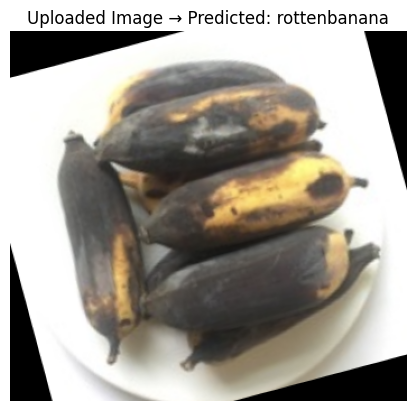


🔎 Prediction Results:
- Predicted Label: rottenbanana
- Accuracy Percentage: 99.52%
- Top 3 Predictions:
   • rottenbanana: 99.52%
   • rottenapples: 0.48%
   • rottenoranges: 0.00%

This image is predicted as **rottenbanana** with 99.52% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 29: Test Prediction Function with Image Display - Upload Sample 1
predict_uploaded_image()

## Step 30: Redefine Prediction Function with Image Display

Redefines the function to show the uploaded image without an overlaid title, keeping the image and the prediction text separate.

In [ ]:
# Step 30: Redefine Prediction Function with Image Display
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image():
    # Step 1: Upload image
    uploaded = files.upload()

    for fn in uploaded.keys():
        img_path = fn
        # Step 2: Preprocess image
        img = image.load_img(img_path, target_size=(128,128))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Step 3: Predict
        prediction = model.predict(img_array)[0]
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class] * 100
        label = class_names[predicted_class]

        # Step 4: Show uploaded image (no text on image)
        plt.imshow(image.load_img(img_path))
        plt.axis("off")
        plt.show()

        # Step 5: Show results separately
        print("\n🔎 Prediction Results:")
        print(f"- Predicted Label: {label}")
        print(f"- Accuracy Percentage: {confidence:.2f}%")
        print(f"- Top 3 Predictions:")
        top_indices = prediction.argsort()[-3:][::-1]
        for i in top_indices:
            print(f"   • {class_names[i]}: {prediction[i]*100:.2f}%")

        # Step 6: Small descriptive paragraph about features
        if "rotten" in label.lower():
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — "
                  f"features the model learned to associate with rotten fruits.")
        else:
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit shows bright color, smooth texture, and firm shape — "
                  f"features the model learned to associate with fresh fruits.")


## Step 31: Test Prediction Function with Image Display - Upload Sample 2

Tests the same prediction function on a Second uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-12 at 8.47.51 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 8.47.51 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


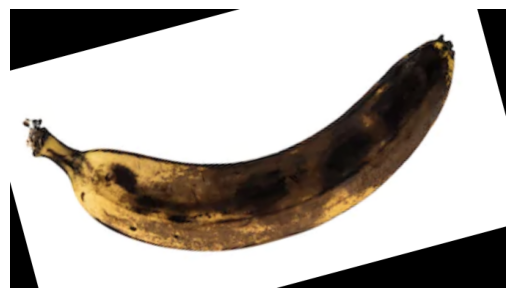


🔎 Prediction Results:
- Predicted Label: rottenbanana
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenbanana: 100.00%
   • rottenoranges: 0.00%
   • rottenapples: 0.00%

This image is predicted as **rottenbanana** with 100.00% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 31: Test Prediction Function with Image Display - Upload Sample 2
predict_uploaded_image()


## Step 32: Test Prediction Function with Image Display - Upload Sample 3

Tests the same prediction function on a Third uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-12 at 11.24.29 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 11.24.29 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


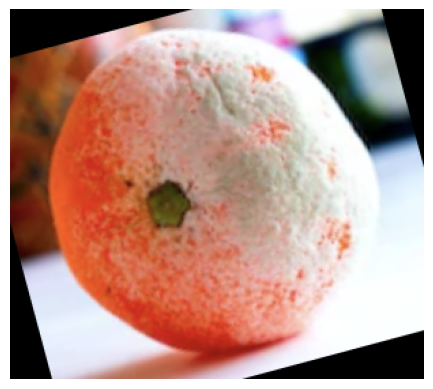


🔎 Prediction Results:
- Predicted Label: rottenoranges
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenoranges: 100.00%
   • apple: 0.00%
   • rottenapples: 0.00%

This image is predicted as **rottenoranges** with 100.00% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 32: Test Prediction Function with Image Display - Upload Sample 3
predict_uploaded_image()

4## Step 33: Test Prediction Function with Image Display - Upload Sample 5

Tests the same prediction function on a fourth uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-07 at 2.20.29 PM.png to rotated_by_15_Screen Shot 2018-06-07 at 2.20.29 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


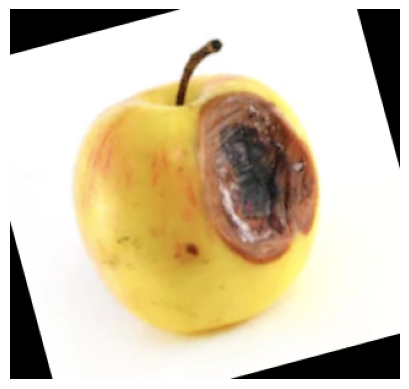


🔎 Prediction Results:
- Predicted Label: rottenapples
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenapples: 100.00%
   • rottenoranges: 0.00%
   • apple: 0.00%

This image is predicted as **rottenapples** with 100.00% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 33: Test Prediction Function with Image Display - Upload Sample 4
predict_uploaded_image()

## Step 34: Test Prediction Function with Image Display - Upload Sample 5

Tests the same prediction function on a fifth uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-07 at 2.16.41 PM.png to rotated_by_15_Screen Shot 2018-06-07 at 2.16.41 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


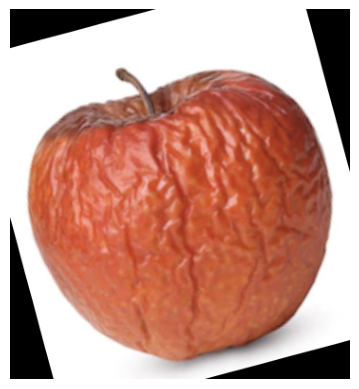


🔎 Prediction Results:
- Predicted Label: rottenapples
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenapples: 100.00%
   • apple: 0.00%
   • rottenoranges: 0.00%

This image is predicted as **rottenapples** with 100.00% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 34: Test Prediction Function with Image Display - Upload Sample 5
predict_uploaded_image()

## Step 35: Test Prediction Function with Image Display - Upload Sample 6

Tests the same prediction function on an sixth uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-08 at 5.14.20 PM.png to rotated_by_15_Screen Shot 2018-06-08 at 5.14.20 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


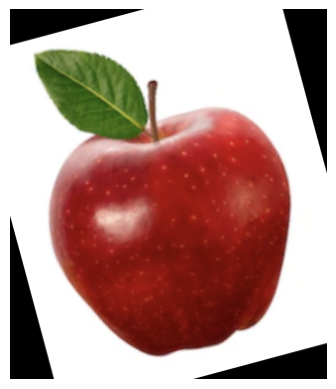


🔎 Prediction Results:
- Predicted Label: apple
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • apple: 100.00%
   • rottenapples: 0.00%
   • rottenoranges: 0.00%

This image is predicted as **apple** with 100.00% confidence. The fruit shows bright color, smooth texture, and firm shape — features the model learned to associate with fresh fruits.


In [ ]:
# Step 35: Test Prediction Function with Image Display - Upload Sample 6
predict_uploaded_image()

## Step 36: Redefine Prediction Function with Extended Description Logic

Extends the explanation logic to separately handle "rotten", "fresh", and any other label cases in the output text.

In [ ]:
# Step 36: Redefine Prediction Function with Extended Description Logic
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image():
    # Step 1: Upload image
    uploaded = files.upload()

    for fn in uploaded.keys():
        img_path = fn
        # Step 2: Preprocess image
        img = image.load_img(img_path, target_size=(128,128))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Step 3: Predict
        prediction = model.predict(img_array)[0]
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class] * 100
        label = class_names[predicted_class]

        # Step 4: Show uploaded image (no text overlay)
        plt.imshow(image.load_img(img_path))
        plt.axis("off")
        plt.show()

        # Step 5: Show results separately
        print("\n🔎 Prediction Results:")
        print(f"- Predicted Label: {label}")
        print(f"- Accuracy Percentage: {confidence:.2f}%")
        print(f"- Top 3 Predictions:")
        top_indices = prediction.argsort()[-3:][::-1]
        for i in top_indices:
            print(f"   • {class_names[i]}: {prediction[i]*100:.2f}%")

        # Step 6: Descriptive explanation for both cases
        if "rotten" in label.lower():
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — "
                  f"features the model learned to associate with rotten fruits.")
        elif "fresh" in label.lower():
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit shows bright, natural color, smooth surface texture, and firm shape — "
                  f"features the model learned to associate with fresh fruits.")
        else:
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The model matched this category based on learned visual features such as color, texture, and shape.")


## Step 37: Redefine Prediction Function with Extended Description Logic

Simplifies the extended description logic back down to a straightforward fresh-vs-rotten explanation.

In [ ]:
# Step 37: Redefine Prediction Function with Extended Description Logic
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image():
    # Step 1: Upload image
    uploaded = files.upload()

    for fn in uploaded.keys():
        img_path = fn
        # Step 2: Preprocess image
        img = image.load_img(img_path, target_size=(128,128))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Step 3: Predict
        prediction = model.predict(img_array)[0]
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class] * 100
        label = class_names[predicted_class]

        # Step 4: Show uploaded image (no text written on image)
        plt.imshow(image.load_img(img_path))
        plt.axis("off")
        plt.show()

        # Step 5: Show results separately
        print("\n🔎 Prediction Results:")
        print(f"- Predicted Label: {label}")
        print(f"- Accuracy Percentage: {confidence:.2f}%")
        print(f"- Top 3 Predictions:")
        top_indices = prediction.argsort()[-3:][::-1]
        for i in top_indices:
            print(f"   • {class_names[i]}: {prediction[i]*100:.2f}%")

        # Step 6: Descriptive explanation
        if "rotten" in label.lower():
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — "
                  f"features the model learned to associate with rotten fruits.")
        else:
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit shows bright, natural color, smooth surface texture, and firm shape — "
                  f"features the model learned to associate with fresh fruits.")


## Step 38: Test Prediction Function with Extended Description - Upload Sample 7

Tests the simplified prediction function on a seventh uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-08 at 5.00.35 PM.png to rotated_by_15_Screen Shot 2018-06-08 at 5.00.35 PM (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


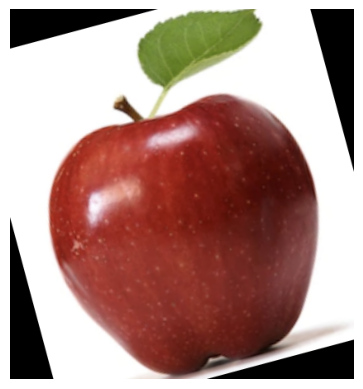


🔎 Prediction Results:
- Predicted Label: apple
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • apple: 100.00%
   • rottenapples: 0.00%
   • rottenoranges: 0.00%

This image is predicted as **apple** with 100.00% confidence. The fruit shows bright, natural color, smooth surface texture, and firm shape — features the model learned to associate with fresh fruits.


In [ ]:
# Step 38: Test Prediction Function with Extended Description - Upload Sample 7
predict_uploaded_image()

## Step 39: Redefine Prediction Function with Label Mapping (Fresh Fruit Renaming)

Adds a label-mapping dictionary so plain class names are displayed as "fresh apple", "fresh banana", etc. in the results.

In [ ]:
# Step 39: Redefine Prediction Function with Label Mapping (Fresh Fruit Renaming)
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Mapping dictionary: plain fruit → fresh fruit
label_mapping = {
    "apple": "fresh apple",
    "banana": "fresh banana",
    "orange": "fresh orange",
    "mango": "fresh mango",
    "grape": "fresh grape"
    # Add more fruits here if your dataset has them
}

def predict_uploaded_image():
    # Step 1: Upload image
    uploaded = files.upload()

    for fn in uploaded.keys():
        img_path = fn
        # Step 2: Preprocess image
        img = image.load_img(img_path, target_size=(128,128))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Step 3: Predict
        prediction = model.predict(img_array)[0]
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class] * 100
        raw_label = class_names[predicted_class]

        # Step 4: Map label to "fresh" if needed
        if raw_label.lower() in label_mapping:
            label = label_mapping[raw_label.lower()]
        else:
            label = raw_label

        # Step 5: Show uploaded image (no text overlay)
        plt.imshow(image.load_img(img_path))
        plt.axis("off")
        plt.show()

        # Step 6: Show results
        print("\n🔎 Prediction Results:")
        print(f"- Predicted Label: {label}")
        print(f"- Accuracy Percentage: {confidence:.2f}%")
        print(f"- Top 3 Predictions:")
        top_indices = prediction.argsort()[-3:][::-1]
        for i in top_indices:
            mapped_name = label_mapping.get(class_names[i].lower(), class_names[i])
            print(f"   • {mapped_name}: {prediction[i]*100:.2f}%")

        # Step 7: Descriptive explanation
        if "rotten" in raw_label.lower():
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — "
                  f"features the model learned to associate with rotten fruits.")
        else:
            print(f"\nThis image is predicted as **{label}** with {confidence:.2f}% confidence. "
                  f"The fruit shows bright, natural color, smooth surface texture, and firm shape — "
                  f"features the model learned to associate with fresh fruits.")


## Step 40: Test Prediction Function with Label Mapping - Upload Sample 8

Tests the label-mapping prediction function on a eight uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-12 at 9.46.19 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 9.46.19 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


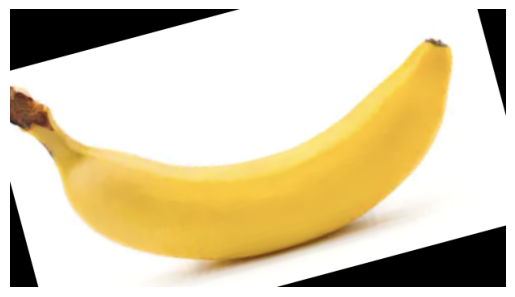


🔎 Prediction Results:
- Predicted Label: fresh banana
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • fresh banana: 100.00%
   • rottenoranges: 0.00%
   • rottenbanana: 0.00%

This image is predicted as **fresh banana** with 100.00% confidence. The fruit shows bright, natural color, smooth surface texture, and firm shape — features the model learned to associate with fresh fruits.


In [ ]:
# Step 40: Test Prediction Function with Label Mapping - Upload Sample 8
predict_uploaded_image()

## Step 41: Test Prediction Function with Label Mapping - Upload Sample 9

Tests the label-mapping prediction function on a ninth uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-12 at 8.51.00 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 8.51.00 PM (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


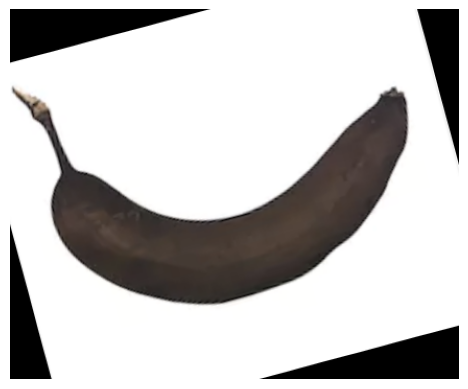


🔎 Prediction Results:
- Predicted Label: rottenbanana
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenbanana: 100.00%
   • rottenoranges: 0.00%
   • rottenapples: 0.00%

This image is predicted as **rottenbanana** with 100.00% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 41: Test Prediction Function with Label Mapping - Upload Sample 9
predict_uploaded_image()

## Step 42: Test Prediction Function with Label Mapping - Upload Sample 10

Tests the label-mapping prediction function on a tenth uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-08 at 5.02.08 PM.png to rotated_by_15_Screen Shot 2018-06-08 at 5.02.08 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


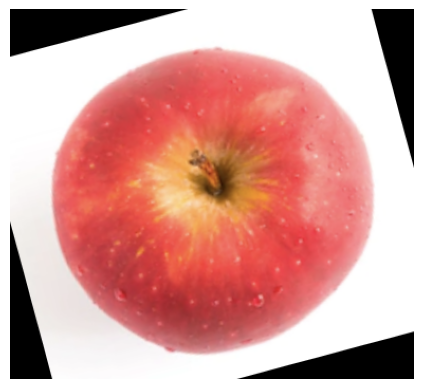


🔎 Prediction Results:
- Predicted Label: fresh apple
- Accuracy Percentage: 99.96%
- Top 3 Predictions:
   • fresh apple: 99.96%
   • rottenapples: 0.04%
   • rottenoranges: 0.00%

This image is predicted as **fresh apple** with 99.96% confidence. The fruit shows bright, natural color, smooth surface texture, and firm shape — features the model learned to associate with fresh fruits.


In [ ]:
# Step 42: Test Prediction Function with Label Mapping - Upload Sample 10
predict_uploaded_image()

## Step 43: Test Prediction Function with Label Mapping - Upload Sample 11

Tests the label-mapping prediction function on a eleventh uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-07 at 2.40.28 PM.png to rotated_by_15_Screen Shot 2018-06-07 at 2.40.28 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


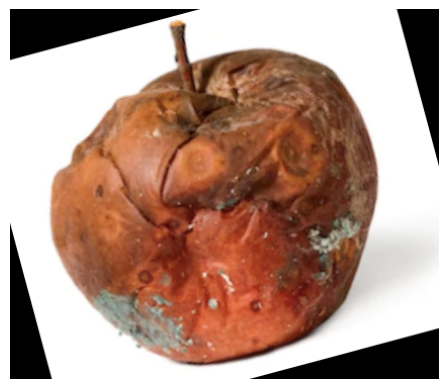


🔎 Prediction Results:
- Predicted Label: rottenapples
- Accuracy Percentage: 98.12%
- Top 3 Predictions:
   • rottenapples: 98.12%
   • rottenoranges: 1.88%
   • fresh apple: 0.00%

This image is predicted as **rottenapples** with 98.12% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 43: Test Prediction Function with Label Mapping - Upload Sample 11
predict_uploaded_image()

## Step 44: Test Prediction Function with Label Mapping - Upload Sample 12

Tests the label-mapping prediction function on a twelfth uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-12 at 11.51.13 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 11.51.13 PM (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


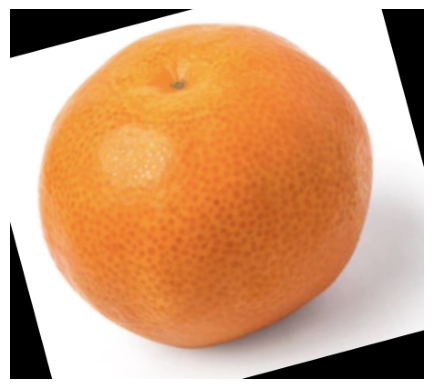


🔎 Prediction Results:
- Predicted Label: fresh orange
- Accuracy Percentage: 99.99%
- Top 3 Predictions:
   • fresh orange: 99.99%
   • rottenoranges: 0.01%
   • rottenapples: 0.00%

This image is predicted as **fresh orange** with 99.99% confidence. The fruit shows bright, natural color, smooth surface texture, and firm shape — features the model learned to associate with fresh fruits.


In [ ]:
# Step 44: Test Prediction Function with Label Mapping - Upload Sample 12
predict_uploaded_image()

## Step 45: Test Prediction Function with Label Mapping - Upload Sample 13

Tests the label-mapping prediction function on a thirteenth uploaded sample image.

Saving rotated_by_15_Screen Shot 2018-06-12 at 11.18.46 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 11.18.46 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


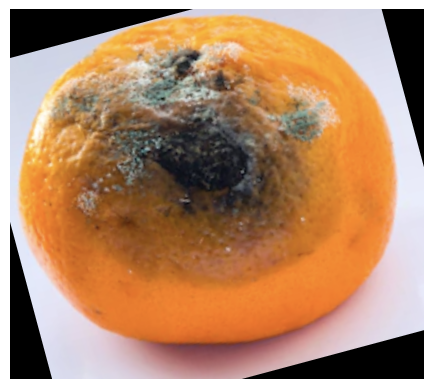


🔎 Prediction Results:
- Predicted Label: rottenoranges
- Accuracy Percentage: 100.00%
- Top 3 Predictions:
   • rottenoranges: 100.00%
   • fresh orange: 0.00%
   • rottenapples: 0.00%

This image is predicted as **rottenoranges** with 100.00% confidence. The fruit appears discolored with darker patches, uneven texture, and signs of softness or decay — features the model learned to associate with rotten fruits.


In [ ]:
# Step 45: Test Prediction Function with Label Mapping - Upload Sample 13
predict_uploaded_image()



# *ADVANTAGES*

1. **Automated Classification**
   The system automatically identifies the fruit category and freshness condition without requiring manual inspection.

2. **High Classification Performance**
   The developed model achieved **95.96% overall accuracy**, demonstrating strong classification performance on the evaluated test dataset.

3. **Multiple Class Detection**
   The model can distinguish between six different fruit-condition categories rather than performing only binary fresh/rotten classification.

4. **Fast Prediction**
   Once trained, the CNN can classify a new image relatively quickly.

5. **User-Friendly Prediction System**
   Users can upload an image and receive the predicted class and confidence score directly.

6. **Reduced Human Subjectivity**
   Automated image analysis can reduce variations that may occur when freshness is judged solely through manual visual inspection.

7. **Practical Application of AI**
   The project demonstrates the practical use of Deep Learning and Computer Vision for a real-world food-quality problem.

# *LIMITATIONS*

1. **Limited Fruit Categories**
   The current model is trained only on six predefined categories: apple, banana, orange, rotten apple, rotten banana, and rotten orange.

2. **Dependence on Training Data**
   The performance of the model depends strongly on the quality, diversity, and distribution of the images used during training.

3. **Image Quality Dependency**
   Poor lighting, blurred images, unusual backgrounds, or partially visible fruits may affect prediction performance.

4. **Limited Generalization**
   The model may not always perform equally well on fruit varieties, camera conditions, or environments that are significantly different from those represented in the dataset.

5. **Freshness Assessment Based on Appearance**
   The system primarily learns visual patterns. It cannot directly determine internal fruit quality, taste, nutritional condition, or contamination that may not be visible externally.

6. **Computational Requirements During Training**
   Training a CNN can require considerable computational resources and is more efficient when suitable hardware acceleration is available.

7. **Confidence Does Not Guarantee Correctness**
   A high prediction confidence represents the model's calculated probability for a class; it should not be interpreted as a guarantee that the prediction is correct.

# *APPLICATIONS*

The proposed AI-based Fruit Freshness Classifier can have several potential applications:

### 1. Food Quality Inspection

The system can assist in identifying visually fresh and rotten fruits during quality inspection.

### 2. Automated Fruit Sorting

The model can potentially be integrated with automated sorting systems to separate fruits based on their visual condition.

### 3. Supermarkets and Retail Stores

Retail environments could use image-based classification to assist staff in identifying fruits that may require removal or replacement.

### 4. Agricultural and Post-Harvest Management

The system can support post-harvest monitoring by helping identify fruits showing visible signs of deterioration.

### 5. Food Storage and Distribution

Automated inspection can potentially assist in monitoring fruit condition during storage and distribution.

### 6. Educational Applications

The project can serve as a practical demonstration of CNNs, image preprocessing, classification, and model evaluation in Artificial Intelligence and Machine Learning.

### 7. Future Smart-Farming Systems

With further development, the model could become part of a larger computer-vision-based agricultural monitoring system.

# *CONCLUSION*

The **AI-Based Fruit Freshness Classification System** successfully demonstrates the application of Convolutional Neural Networks for classifying fruit images according to their type and visible freshness condition. The developed model processes images at a standardized resolution of 128 × 128 pixels and uses convolutional and pooling layers to automatically learn important visual features. The final softmax layer classifies each image into one of six predefined categories.

The model was trained and evaluated using a substantial image dataset containing **9,453 training images and 1,879 test images**. The evaluation produced an overall **accuracy of 95.96%**, with **96.10% macro precision, 95.89% macro recall, and 95.98% macro F1-score**. These results indicate that the model achieved strong performance on the evaluated dataset.

The project also provides a practical image-prediction function through which users can upload a new fruit image and obtain the predicted class, confidence score, and top three predictions.

In conclusion, the project demonstrates that Deep Learning and Computer Vision can be effectively applied to automate visual fruit classification and freshness assessment. Although the current system is limited to the six categories represented in its dataset and primarily evaluates visible characteristics, it provides a strong foundation for future improvements. With a larger and more diverse dataset, additional fruit varieties, improved model architectures, and real-world image testing, the system could be further developed for practical applications in **food quality inspection, automated sorting, retail, agriculture, and post-harvest management**.
